<a href="https://colab.research.google.com/github/an2ancan/combinatorics-ml/blob/main/TSP_Model_Seq2Seq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TSP Neural Solver — Sequence-to-Sequence (Pointer Network)

This notebook implements and trains a **Sequence-to-Sequence (Seq2Seq)** neural network with **Pointer Attention** (Vinyals et al., 2015; Bello et al., 2016) to solve the **Travelling Salesman Problem (TSP)**.

---

### Architecture Overview

Standard Seq2Seq models with fixed-vocabulary softmax cannot solve TSP because:
1. The output vocabulary size varies with the input sequence length $N$.
2. The output sequence must be a valid permutation of the input nodes (each city visited exactly once).

The **Pointer Network** solves this by using attention scores as pointers to input positions:

```text
Input Coordinates X: [x_1, x_2, ..., x_N] in [0, 1]^2
       |
       v
+--------------------------------------------------------+
|  Embedding: e_i = W_x * x_i + b_x                      |
|  Encoder  : Bidirectional LSTM -> [h_1, ..., h_N]      |
+---------------------------+----------------------------+
                            | (Encoder outputs H)
                            v
+--------------------------------------------------------+
|  Decoder (Autoregressive LSTMCell at step t):          |
|  - Hidden state: d_t = LSTMCell(input_t, (d_{t-1}, c)) |
|  - Attention scores: u_i^t = v^T tanh(W_e*h_i + W_d*d_t)|
|  - Dynamic Masking: u_i^t = -inf if i already visited  |
|  - Pointer Probabilities: p_t = softmax(u^t)           |
|  - Action selection: pi_t ~ Categorical(p_t) (sample)  |
|                      or pi_t = argmax(p_t) (greedy)    |
+--------------------------------------------------------+
```

### Training via Reinforcement Learning (REINFORCE)

The network is trained directly on unlabelled coordinate tensors (`train.npy`) using the **REINFORCE policy gradient algorithm** with an **Exponential Moving Average (EMA) baseline**:

$$\mathcal{L}(\theta) = \mathbb{E}_{X \sim \mathcal{D}} \left[ (L(\pi) - b) \sum_{t=1}^N \log P_\theta(\pi_t \mid \pi_{1:t-1}, X) \right]$$

where $L(\pi)$ is the total Euclidean tour length and $b$ is the EMA baseline.

---
## 1 — Install & Import Dependencies

In [1]:
!pip install -q torch torchvision torchaudio matplotlib tqdm scipy pandas

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device      : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU Device      : Tesla T4


---
## 2 — Environment & Google Drive Setup

In [2]:
# Try loading environment variables from .env if present
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

# Detect environment: Colab vs Local
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')
RUN_LOCALLY = os.getenv('RUN_LOCALLY', str(not IN_COLAB)).lower() in ('true', '1', 'yes')

if IN_COLAB and not RUN_LOCALLY:
    from google.colab import drive
    drive.mount('/content/drive')
    print('[OK] Google Drive mounted.')
else:
    print(f'[INFO] Running in local mode (RUN_LOCALLY={RUN_LOCALLY}). Using local paths.')

# Device selection (CUDA -> MPS -> CPU)
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f"[INFO] Using compute device: {DEVICE}")

Mounted at /content/drive
[OK] Google Drive mounted.
[INFO] Using compute device: cuda


---
## 3 — Configuration

In [3]:
# ── Problem & Data Settings ──────────────────────────────────────────────────
TSP_SIZE = 20  # problem size to train and evaluate (10, 20, 50, 100, etc.)
NUM_TRAIN_SAMPLES = None  # None for all 128,000 instances, or integer to subset
NUM_VAL_SAMPLES = 1000  # number of validation instances for evaluation

# ── Model Architecture Hyperparameters ───────────────────────────────────────
INPUT_DIM = 2
EMBEDDING_DIM = 128
HIDDEN_DIM = 128

# ── Training Hyperparameters ─────────────────────────────────────────────────
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
NUM_EPOCHS = 10
BETA_BASELINE = 0.9  # Exponential moving average factor for REINFORCE baseline
GRAD_CLIP_NORM = 1.0
SEED = 42

# ── Paths ────────────────────────────────────────────────────────────────────
if RUN_LOCALLY:
    DATA_DIR = os.getenv('TSP_DATA_DIR', './TSP_Data')
    RESULTS_DIR = os.getenv('TSP_RESULTS_DIR', './TSP_Data/baseline_results')
    CHECKPOINT_DIR = './checkpoints'
else:
    DATA_DIR = '/content/drive/MyDrive/TSP_Data'
    RESULTS_DIR = '/content/drive/MyDrive/TSP_Data/baseline_results'
    CHECKPOINT_DIR = '/content/drive/MyDrive/TSP_Data/checkpoints'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Problem size      : TSP-{TSP_SIZE}")
print(f"Embedding / Hidden: {EMBEDDING_DIM} / {HIDDEN_DIM}")
print(f"Batch size / LR   : {BATCH_SIZE} / {LEARNING_RATE}")
print(f"Epochs / Baseline : {NUM_EPOCHS} / EMA (beta={BETA_BASELINE})")
print(f"Device            : {DEVICE}")

Problem size      : TSP-20
Embedding / Hidden: 128 / 128
Batch size / LR   : 256 / 0.001
Epochs / Baseline : 10 / EMA (beta=0.9)
Device            : cuda


---
## 4 — PyTorch Dataset & DataLoader

Load the uniform 2D TSP datasets generated in the data generation stage.

In [4]:
class TSPDataset(Dataset):
    """
    PyTorch Dataset for TSP coordinate instances.

    Parameters
    ----------
    npy_path : str
        Path to .npy file containing array of shape (num_samples, num_nodes, 2)
    max_samples : int, optional
        Maximum number of samples to load (useful for fast debugging)
    """
    def __init__(self, npy_path: str, max_samples: int = None):
        if not os.path.exists(npy_path):
            raise FileNotFoundError(f"[ERROR] Dataset file not found: {npy_path}")
        data = np.load(npy_path).astype(np.float32)
        if max_samples is not None and max_samples < len(data):
            data = data[:max_samples]
        self.data = torch.from_numpy(data)

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> torch.Tensor:
        return self.data[idx]

# Load training and validation datasets
train_path = os.path.join(DATA_DIR, f'tsp_{TSP_SIZE}', 'train.npy')
val_path = os.path.join(DATA_DIR, f'tsp_{TSP_SIZE}', 'val.npy')

train_dataset = TSPDataset(train_path, max_samples=NUM_TRAIN_SAMPLES)
val_dataset = TSPDataset(val_path, max_samples=NUM_VAL_SAMPLES)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print(f"[OK] Loaded {len(train_dataset):,} train instances and {len(val_dataset):,} val instances for TSP-{TSP_SIZE}.")

[OK] Loaded 128,000 train instances and 1,000 val instances for TSP-20.


---
## 5 — Model Architecture (Pointer Network)

The architecture consists of:
1. **PointerAttention**: Computes dynamic pointing scores $u_i^t$ over all encoder representations, masking out visited cities.
2. **Encoder**: Projects 2D node coordinates and applies a Bidirectional LSTM.
3. **Decoder**: Autoregressively generates the tour $\pi$ step-by-step using an LSTMCell with dynamic attention weights.

In [5]:
class PointerAttention(nn.Module):
    """
    Bahdanau-style Pointer Attention mechanism with dynamic masking.

    Parameters
    ----------
    hidden_dim : int
        Hidden state dimension
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.W_e = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W_d = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(
        self,
        enc_outputs: torch.Tensor,
        dec_hidden: torch.Tensor,
        mask: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Parameters
        ----------
        enc_outputs : torch.Tensor, shape (B, N, H)
        dec_hidden  : torch.Tensor, shape (B, H)
        mask        : torch.Tensor, shape (B, N), bool (True = already visited)

        Returns
        -------
        probs : torch.Tensor, shape (B, N)
        log_probs : torch.Tensor, shape (B, N)
        """
        enc_proj = self.W_e(enc_outputs)               # (B, N, H)
        dec_proj = self.W_d(dec_hidden).unsqueeze(1)    # (B, 1, H)
        scores = self.v(torch.tanh(enc_proj + dec_proj)).squeeze(-1)  # (B, N)

        # Dynamic masking for visited nodes
        scores = scores.masked_fill(mask, -1e9)

        log_probs = F.log_softmax(scores, dim=-1)       # (B, N)
        probs = F.softmax(scores, dim=-1)               # (B, N)
        return probs, log_probs


class PointerNetwork(nn.Module):
    """
    Pointer Network for solving Travelling Salesman Problem.

    Parameters
    ----------
    input_dim : int, default 2
        Input coordinate dimension (2D coordinates in [0, 1])
    embedding_dim : int, default 128
        Node embedding projection dimension
    hidden_dim : int, default 128
        LSTM hidden dimension
    """
    def __init__(
        self,
        input_dim: int = INPUT_DIM,
        embedding_dim: int = EMBEDDING_DIM,
        hidden_dim: int = HIDDEN_DIM,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.embedding_dim = embedding_dim

        # Node embedding & Bidirectional Encoder
        self.embedding = nn.Linear(input_dim, embedding_dim)
        self.encoder = nn.LSTM(
            embedding_dim,
            hidden_dim // 2,
            batch_first=True,
            bidirectional=True,
        )

        # Autoregressive Decoder & Pointer Attention
        self.decoder_cell = nn.LSTMCell(embedding_dim, hidden_dim)
        self.pointer = PointerAttention(hidden_dim)

        # Learnable start token embedding for the first decoding step
        self.start_placeholder = nn.Parameter(torch.randn(embedding_dim))

    def forward(
        self,
        coords: torch.Tensor,
        decode_type: str = 'sample',
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass generating a permutation of the input nodes.

        Parameters
        ----------
        coords : torch.Tensor, shape (B, N, 2)
        decode_type : str, 'sample' for exploration or 'greedy' for evaluation

        Returns
        -------
        tour : torch.Tensor, shape (B, N), long node indices
        total_log_probs : torch.Tensor, shape (B,), sum of log probabilities of selected actions
        """
        B, N, _ = coords.shape

        # 1. Embed and encode
        embedded = self.embedding(coords)               # (B, N, E)
        enc_outputs, (h_n, c_n) = self.encoder(embedded) # (B, N, H)

        # 2. Initial decoder hidden state (mean-pooled encoder representations)
        h_t = enc_outputs.mean(dim=1)                   # (B, H)
        c_t = torch.zeros_like(h_t)                     # (B, H)

        # Start token for step t=0
        dec_input = self.start_placeholder.unsqueeze(0).expand(B, -1)  # (B, E)

        mask = torch.zeros(B, N, dtype=torch.bool, device=coords.device)
        tour = []
        log_probs_list = []

        # 3. Autoregressive unrolling
        for step in range(N):
            h_t, c_t = self.decoder_cell(dec_input, (h_t, c_t))
            probs, log_probs = self.pointer(enc_outputs, h_t, mask)

            if decode_type == 'greedy':
                action = probs.argmax(dim=-1)          # (B,)
            else:
                dist = torch.distributions.Categorical(probs)
                action = dist.sample()                 # (B,)

            selected_log_prob = log_probs.gather(1, action.unsqueeze(1)).squeeze(1)
            log_probs_list.append(selected_log_prob)

            # Non-in-place mask update to preserve autograd graph
            mask = mask.clone()
            mask.scatter_(1, action.unsqueeze(1), True)
            tour.append(action)

            # Next input is the embedding of the selected node
            batch_idx = torch.arange(B, device=coords.device)
            dec_input = embedded[batch_idx, action]    # (B, E)

        tour = torch.stack(tour, dim=1)                 # (B, N)
        total_log_probs = torch.stack(log_probs_list, dim=1).sum(dim=1)  # (B,)
        return tour, total_log_probs

---
## 6 — Loss & Tour Length Utilities

Vectorized Euclidean closed tour length calculation: $\sum_{i=1}^N \|x_{\pi_i} - x_{\pi_{i+1}}\|_2 + \|x_{\pi_N} - x_{\pi_1}\|_2$.

In [6]:
def compute_tour_lengths(coords: torch.Tensor, tour: torch.Tensor) -> torch.Tensor:
    """
    Compute the true Euclidean closed tour length for a batch of TSP instances.

    Parameters
    ----------
    coords : torch.Tensor, shape (B, N, 2)
    tour   : torch.Tensor, shape (B, N), permutation of node indices

    Returns
    -------
    torch.Tensor, shape (B,), total Euclidean distance per instance
    """
    B, N, _ = coords.shape
    batch_idx = torch.arange(B, device=coords.device).unsqueeze(1).expand(B, N)
    ordered_coords = coords[batch_idx, tour]                    # (B, N, 2)
    next_coords = torch.roll(ordered_coords, shifts=-1, dims=1) # (B, N, 2)
    segment_lengths = torch.norm(next_coords - ordered_coords, p=2, dim=-1)  # (B, N)
    return segment_lengths.sum(dim=1)                          # (B,)


@torch.no_grad()
def evaluate_model(model: nn.Module, dataloader: DataLoader, device: torch.device) -> dict:
    """
    Evaluate the model on a validation dataset using greedy decoding.

    Returns
    -------
    dict with keys: 'mean_tour_length', 'std_tour_length', 'all_lengths'
    """
    model.eval()
    all_lengths = []
    for batch in dataloader:
        coords = batch.to(device)
        tours, _ = model(coords, decode_type='greedy')
        lengths = compute_tour_lengths(coords, tours)
        all_lengths.extend(lengths.cpu().numpy().tolist())

    all_lengths = np.array(all_lengths, dtype=np.float32)
    return {
        'mean_tour_length': float(all_lengths.mean()),
        'std_tour_length': float(all_lengths.std()),
        'min_tour_length': float(all_lengths.min()),
        'max_tour_length': float(all_lengths.max()),
        'all_lengths': all_lengths,
    }

---
## 7 — Quick Smoke Test

Run a forward pass on a small batch of 4 instances to verify the pipeline and tour validity.

In [7]:
test_model = PointerNetwork(input_dim=2, embedding_dim=EMBEDDING_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)
dummy_batch = torch.rand(4, TSP_SIZE, 2, device=DEVICE)

# 1. Greedy evaluation
with torch.no_grad():
    greedy_tours, greedy_log_probs = test_model(dummy_batch, decode_type='greedy')
    greedy_lengths = compute_tour_lengths(dummy_batch, greedy_tours)

# 2. Sample evaluation
sample_tours, sample_log_probs = test_model(dummy_batch, decode_type='sample')
sample_lengths = compute_tour_lengths(dummy_batch, sample_tours)

print("Forward pass verification:")
print(f"  Greedy tours shape : {greedy_tours.shape}")
print(f"  Greedy lengths     : {greedy_lengths.cpu().numpy().round(4)}")
print(f"  Sample tours shape : {sample_tours.shape}")
print(f"  Sample lengths     : {sample_lengths.cpu().numpy().round(4)}")

# Check if each tour is a valid permutation of [0, ..., N-1]
for i in range(len(dummy_batch)):
    unique_nodes = torch.unique(greedy_tours[i]).cpu().numpy()
    assert len(unique_nodes) == TSP_SIZE, f"Tour {i} is invalid! Visited {len(unique_nodes)} unique nodes."

print("\n[OK] Smoke test passed! Valid tours generated.")

Forward pass verification:
  Greedy tours shape : torch.Size([4, 20])
  Greedy lengths     : [ 8.4382  8.8074  9.4298 10.5929]
  Sample tours shape : torch.Size([4, 20])
  Sample lengths     : [10.8204 10.216   8.6153 10.7243]

[OK] Smoke test passed! Valid tours generated.


---
## 8 — Training Loop (REINFORCE with EMA Baseline)

Train the Pointer Network by minimizing the expected tour length on the training set.

In [8]:
model = PointerNetwork(
    input_dim=INPUT_DIM,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Exponential moving average (EMA) baseline tracker
ema_baseline = None

# Training metrics history
history = {
    'epoch': [],
    'train_loss': [],
    'train_tour_length': [],
    'val_tour_length': [],
    'epoch_time': [],
}

best_val_length = float('inf')
best_checkpoint_path = os.path.join(CHECKPOINT_DIR, f'best_pointer_net_tsp_{TSP_SIZE}.pt')

# Initial zero-shot validation score
init_val = evaluate_model(model, val_loader, DEVICE)
print(f"[INFO] Initial untrained validation tour length: {init_val['mean_tour_length']:.4f} +- {init_val['std_tour_length']:.4f}\n")

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_losses = []
    epoch_lengths = []
    t_start = time.time()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{NUM_EPOCHS:02d}", leave=True)
    for batch in pbar:
        coords = batch.to(DEVICE)
        optimizer.zero_grad()

        # Sample tours from policy
        tours, log_probs = model(coords, decode_type='sample')
        lengths = compute_tour_lengths(coords, tours)

        mean_batch_length = lengths.mean().item()
        if ema_baseline is None:
            ema_baseline = mean_batch_length
        else:
            ema_baseline = BETA_BASELINE * ema_baseline + (1.0 - BETA_BASELINE) * mean_batch_length

        # Advantage = (Length - Baseline)
        advantage = lengths - ema_baseline
        loss = (advantage.detach() * log_probs).mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()

        epoch_losses.append(loss.item())
        epoch_lengths.append(mean_batch_length)
        pbar.set_postfix({
            'loss': f"{np.mean(epoch_losses[-50:]):.4f}",
            'len': f"{np.mean(epoch_lengths[-50:]):.4f}",
            'base': f"{ema_baseline:.4f}",
        })

    epoch_time = time.time() - t_start
    train_loss = float(np.mean(epoch_losses))
    train_length = float(np.mean(epoch_lengths))

    # Evaluate on validation dataset (greedy decoding)
    val_metrics = evaluate_model(model, val_loader, DEVICE)
    val_length = val_metrics['mean_tour_length']

    # Save history
    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['train_tour_length'].append(train_length)
    history['val_tour_length'].append(val_length)
    history['epoch_time'].append(epoch_time)

    # Checkpoint best model
    saved_flag = ''
    if val_length < best_val_length:
        best_val_length = val_length
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_tour_length': val_length,
            'tsp_size': TSP_SIZE,
            'hidden_dim': HIDDEN_DIM,
            'embedding_dim': EMBEDDING_DIM,
        }, best_checkpoint_path)
        saved_flag = ' [BEST MODEL SAVED]'

    print(f"Epoch {epoch:02d} | Train Len: {train_length:.4f} | Val Len: {val_length:.4f} | Loss: {train_loss:.4f} | Time: {epoch_time:.1f}s{saved_flag}")

print(f"\n[OK] Training completed! Best validation tour length: {best_val_length:.4f}")

[INFO] Initial untrained validation tour length: 8.6927 +- 1.1535



Epoch 01/10:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 01 | Train Len: 5.5620 | Val Len: 4.0949 | Loss: 1.7056 | Time: 26.2s [BEST MODEL SAVED]


Epoch 02/10:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 02 | Train Len: 4.1540 | Val Len: 4.0766 | Loss: -0.2372 | Time: 24.8s [BEST MODEL SAVED]


...

Epoch 08 | Train Len: 4.0389 | Val Len: 4.0105 | Loss: -0.0810 | Time: 23.9s [BEST MODEL SAVED]


Epoch 09/10:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 09 | Train Len: 4.0353 | Val Len: 4.0135 | Loss: -0.0778 | Time: 24.0s


Epoch 10/10:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 10 | Train Len: 4.0315 | Val Len: 4.0070 | Loss: -0.0758 | Time: 23.0s [BEST MODEL SAVED]

[OK] Training completed! Best validation tour length: 4.0070


---
## 9 — Training Curves & Analysis

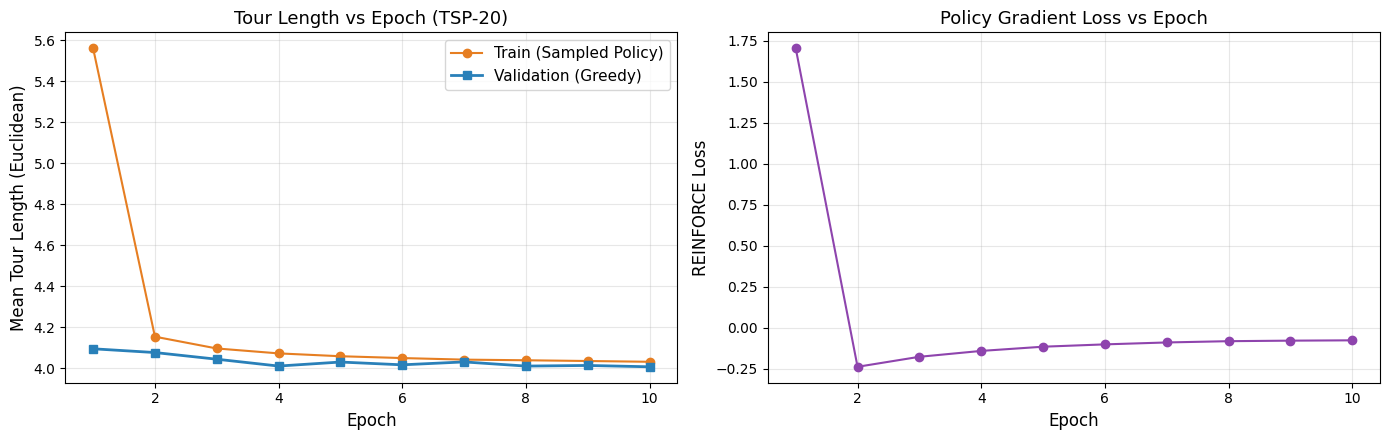

In [9]:
epochs = history['epoch']
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Plot 1: Tour Length Progression (Train Sample vs Val Greedy)
axes[0].plot(epochs, history['train_tour_length'], 'o-', label='Train (Sampled Policy)', color='#E67E22')
axes[0].plot(epochs, history['val_tour_length'], 's-', label='Validation (Greedy)', color='#2980B9', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Mean Tour Length (Euclidean)', fontsize=12)
axes[0].set_title(f'Tour Length vs Epoch (TSP-{TSP_SIZE})', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)

# Plot 2: REINFORCE Policy Loss
axes[1].plot(epochs, history['train_loss'], 'o-', color='#8E44AD', linewidth=1.5)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('REINFORCE Loss', fontsize=12)
axes[1].set_title('Policy Gradient Loss vs Epoch', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 10 — Benchmark Comparison vs OR-Tools / Concorde Baselines

Compute the **optimality gap** of the trained Seq2Seq model against classical solvers:  
$$\text{Gap} = \frac{\bar{L}_{\text{seq2seq}} - \bar{L}_{\text{baseline}}}{\bar{L}_{\text{baseline}}} \times 100\%$$


In [10]:
# Load best model checkpoint for final benchmark
checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Full validation evaluation
t0 = time.time()
final_val_metrics = evaluate_model(model, val_loader, DEVICE)
val_wall_time = time.time() - t0
model_mean = final_val_metrics['mean_tour_length']
model_std = final_val_metrics['std_tour_length']

print(f"Seq2Seq (Pointer Net) Final Metrics (TSP-{TSP_SIZE}):")
print(f"  Mean Tour Length : {model_mean:.4f} +- {model_std:.4f}")
print(f"  Inference Time   : {val_wall_time:.2f}s for {len(val_dataset)} instances ({val_wall_time/len(val_dataset)*1000:.2f} ms/instance)")

# Load OR-Tools baseline summary if available
ortools_summary_path = os.path.join(RESULTS_DIR, 'ortools_summary.csv')
if os.path.exists(ortools_summary_path):
    ortools_df = pd.read_csv(ortools_summary_path)
    row = ortools_df[ortools_df['TSP Size'] == TSP_SIZE]
    if not row.empty:
        ortools_mean = float(row['Tour Length (mean)'].values[0])
        gap_ortools = ((model_mean - ortools_mean) / ortools_mean) * 100.0
        print(f"\nComparison with OR-Tools Baseline:")
        print(f"  OR-Tools Mean Length: {ortools_mean:.4f}")
        print(f"  Seq2Seq Mean Length : {model_mean:.4f}")
        print(f"  Gap vs OR-Tools     : {gap_ortools:+.2f}%")

# Load Concorde baseline summary if available
concorde_summary_path = os.path.join(RESULTS_DIR, 'concorde_summary.csv')
if os.path.exists(concorde_summary_path):
    concorde_df = pd.read_csv(concorde_summary_path)
    row = concorde_df[concorde_df['TSP Size'] == TSP_SIZE]
    if not row.empty:
        concorde_mean = float(row['Tour Length (Mean)'].values[0])
        gap_concorde = ((model_mean - concorde_mean) / concorde_mean) * 100.0
        print(f"\nComparison with Concorde (Exact Ground Truth):")
        print(f"  Concorde Optimal    : {concorde_mean:.4f}")
        print(f"  Gap vs Optimal      : {gap_concorde:+.2f}%")

Seq2Seq (Pointer Net) Final Metrics (TSP-20):
  Mean Tour Length : 4.0070 +- 0.3596
  Inference Time   : 0.06s for 1000 instances (0.06 ms/instance)

Comparison with OR-Tools Baseline:
  OR-Tools Mean Length: 3.8505
  Seq2Seq Mean Length : 4.0070
  Gap vs OR-Tools     : +4.06%


---
## 11 — Visualise Solved Tours

Plot predicted tours generated by the Pointer Network on sample validation instances.

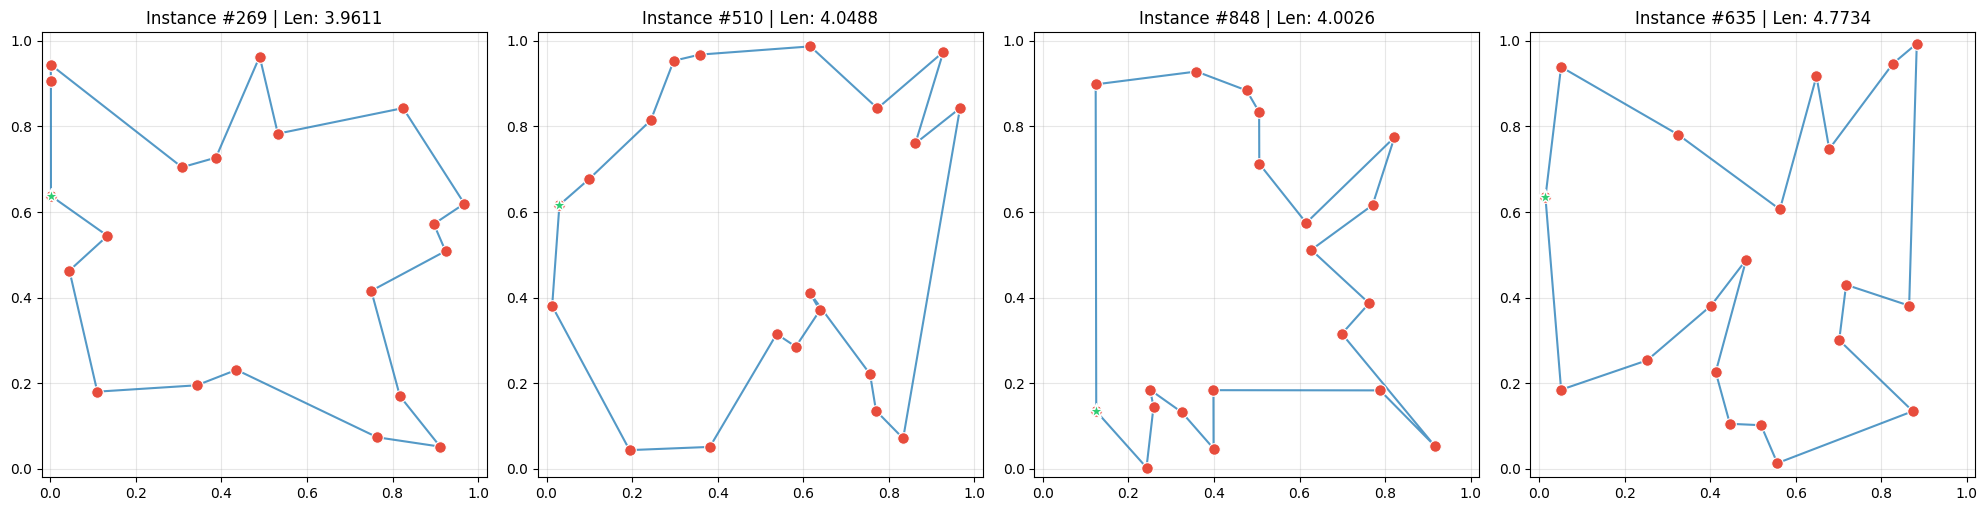

In [11]:
# Pick 4 random validation instances to visualise
rng = np.random.default_rng(0)
sample_indices = rng.choice(len(val_dataset), size=4, replace=False)
sample_coords = torch.stack([val_dataset[i] for i in sample_indices]).to(DEVICE)

with torch.no_grad():
    sample_tours, _ = model(sample_coords, decode_type='greedy')
    sample_lengths = compute_tour_lengths(sample_coords, sample_tours)

sample_coords_np = sample_coords.cpu().numpy()
sample_tours_np = sample_tours.cpu().numpy()
sample_lengths_np = sample_lengths.cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i in range(4):
    ax = axes[i]
    coords = sample_coords_np[i]
    tour = sample_tours_np[i]
    tour_closed = list(tour) + [tour[0]]
    tour_coords = coords[tour_closed]

    # Draw tour edges
    ax.plot(tour_coords[:, 0], tour_coords[:, 1], '-', color='#2980B9', linewidth=1.5, alpha=0.8, zorder=2)
    # Draw city nodes
    ax.scatter(coords[:, 0], coords[:, 1], c='#E74C3C', s=70, edgecolors='white', linewidths=0.8, zorder=3)
    # Highlight first city
    ax.scatter(coords[tour[0], 0], coords[tour[0], 1], c='#2ECC71', s=120, edgecolors='white', linewidths=1.2, zorder=4, marker='*')

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')
    ax.set_title(f'Instance #{sample_indices[i]} | Len: {sample_lengths_np[i]:.4f}', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 12 — Save Model Artifacts & Summary

In [12]:
# Save summary config & history
summary_data = {
    'tsp_size': TSP_SIZE,
    'num_train_samples': len(train_dataset),
    'num_val_samples': len(val_dataset),
    'embedding_dim': EMBEDDING_DIM,
    'hidden_dim': HIDDEN_DIM,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'num_epochs': NUM_EPOCHS,
    'best_val_tour_length': best_val_length,
    'checkpoint_path': best_checkpoint_path,
    'history': history,
}

summary_json_path = os.path.join(RESULTS_DIR, f'seq2seq_summary_tsp_{TSP_SIZE}.json')
with open(summary_json_path, 'w') as f:
    json.dump(summary_data, f, indent=2)

print(f"[OK] Saved model summary and metrics -> {summary_json_path}")
print(f"[OK] Best model weights checkpoint   -> {best_checkpoint_path}")

[OK] Saved model summary and metrics -> /content/drive/MyDrive/TSP_Data/baseline_results/seq2seq_summary_tsp_20.json
[OK] Best model weights checkpoint   -> /content/drive/MyDrive/TSP_Data/checkpoints/best_pointer_net_tsp_20.pt
